<a href="https://colab.research.google.com/github/irfadillah30/DS29/blob/main/IRFADILLAH_AFNI_NURVITA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Irfadillah Afni Nurvita
# Ds29
# Take Home Test
* Data set yang digunakan : "Zomato Delivery Operations Analytics"

# Problem Statement:

"Bagaimana cara memprediksi waktu pengantaran (Time_taken) secara akurat berdasarkan atribut operasional dan lingkungan seperti kondisi lalu lintas, usia kurir, dan informasi jumlah pengantaran?"

# Tujuan Proyek:

Membangun model prediktif berbasis data untuk memperkirakan waktu pengantaran, guna meningkatkan akurasi estimasi waktu kepada pelanggan dan efisiensi operasional Zomato.

# Data preprocessing

In [ ]:
# import library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV



In [ ]:
# Load dataset
df = pd.read_csv("Zomato Dataset.csv")

In [ ]:
# 1. Cek data awal
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

In [ ]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken (min)
count,43730.000000,43676.000000,45584.000000,45584.000000,45584.000000,45584.000000,45584.000000,44591.000000,45584.000000
mean,29.566911,4.633774,17.017948,70.229684,17.465480,70.844161,1.023385,0.744635,26.293963
std,5.815064,0.334744,8.185674,22.885575,7.335562,21.120578,0.839055,0.572510,9.384298
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.551440,75.897963,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


In [ ]:
# 2. Cek missing values
missing = df.isnull().sum()
print("Missing values:\n", missing)


Missing values:
 ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken (min)                  0
dtype: int64


In [ ]:
# Drop baris dengan missing value
df.dropna(inplace=True)
# cek missing value lagi
missing = df.isnull().sum()
print("Missing values after dropping:\n", missing)

Missing values after dropping:
 ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
dtype: int64


In [ ]:
#3. Cek data duplikat
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [ ]:
#4. cek tipe data
print("Data types:\n", df.dtypes)

Data types:
 ID                              object
Delivery_person_ID              object
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weather_conditions              object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken (min)                 int64
dtype: object


In [ ]:
# 5. Ubah tipe data kolom waktu
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d/%m/%Y',errors='coerce')
df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], format='%H:%M:%S', errors='coerce')
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], format='%H:%M:%S', errors='coerce')

In [ ]:
# 6. ubah kolom numerik
df['Delivery_person_Age'] = df['Delivery_person_Age'].astype(int)
df['multiple_deliveries'] = df['multiple_deliveries'].astype(int)

In [ ]:
# 7. encoding
df_encode = pd.get_dummies(df, columns=[
    'Weather_conditions',
    'Road_traffic_density',
    'Type_of_order',
    'Type_of_vehicle',
    'Festival',
    'City'
], drop_first=True)

In [ ]:
# 8. cek kembali data yang siap digunakan
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41359 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           41359 non-null  object        
 1   Delivery_person_ID           41359 non-null  object        
 2   Delivery_person_Age          41359 non-null  int64         
 3   Delivery_person_Ratings      41359 non-null  float64       
 4   Restaurant_latitude          41359 non-null  float64       
 5   Restaurant_longitude         41359 non-null  float64       
 6   Delivery_location_latitude   41359 non-null  float64       
 7   Delivery_location_longitude  41359 non-null  float64       
 8   Order_Date                   0 non-null      datetime64[ns]
 9   Time_Orderd                  0 non-null      datetime64[ns]
 10  Time_Order_picked            0 non-null      datetime64[ns]
 11  Weather_conditions           41359 non-null  o

# Exploratory Data Analyst

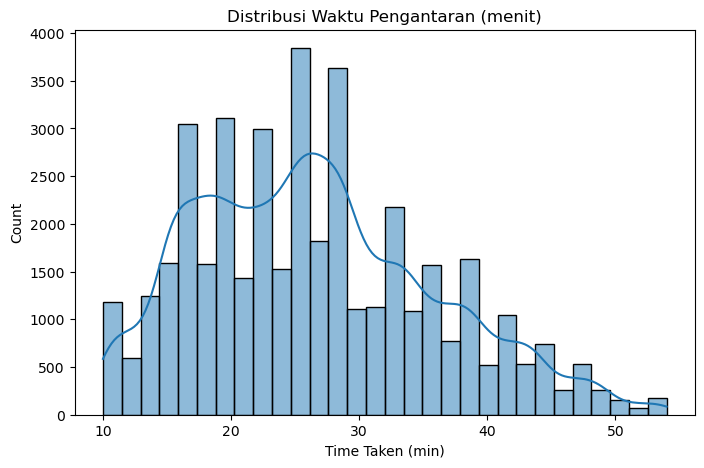

In [ ]:
# Distribusi waktu pengantaran
plt.figure(figsize=(8,5))
sns.histplot(df['Time_taken (min)'], bins=30, kde=True)
plt.title("Distribusi Waktu Pengantaran (menit)")
plt.xlabel("Time Taken (min)")
plt.show()

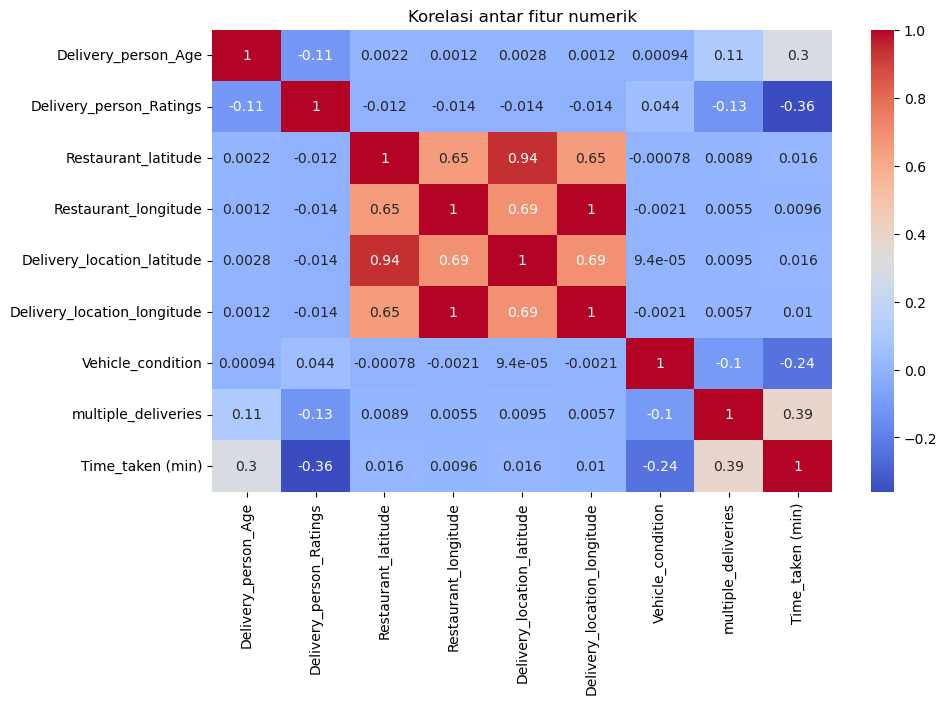

In [ ]:
# Korelasi fitur numerik
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Korelasi antar fitur numerik")
plt.show()

Kurir yang lebih muda dan memiliki rating lebih tinggi cenderung lebih cepat dalam mengantar.
Jarak geografis antara restoran dan pelanggan sering kali linear, terlihat dari korelasi koordinat yang sangat tinggi.

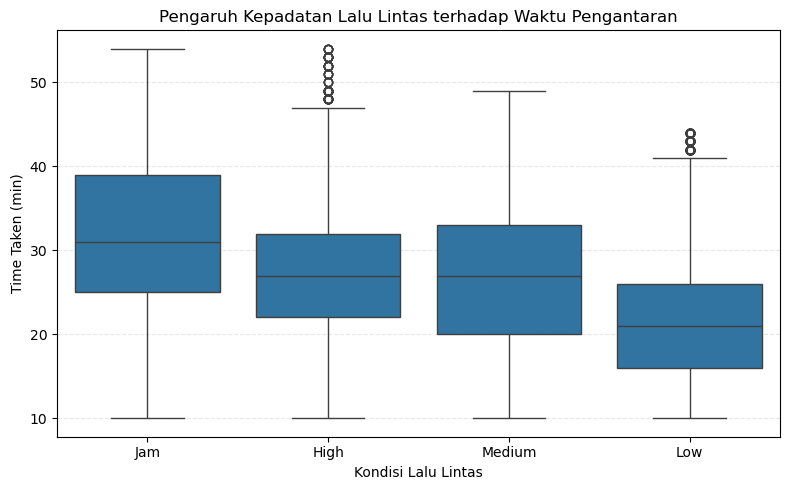

In [ ]:
# Boxplot waktu pengantaran berdasarkan lalu lintas
plt.figure(figsize=(8,5))
sns.boxplot(x="Road_traffic_density", y="Time_taken (min)", data=df)
plt.title("Pengaruh Kepadatan Lalu Lintas terhadap Waktu Pengantaran")
plt.xlabel("Kondisi Lalu Lintas")
plt.ylabel("Time Taken (min)")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Statistik deskriptif waktu pengantaran berdasarkan kondisi lalu lintas
traffic_stats = df.groupby("Road_traffic_density")["Time_taken (min)"].describe()
print(traffic_stats)

                        count       mean       std   min   25%   50%   75%  \
Road_traffic_density                                                         
High                   4101.0  27.407218  8.298162  10.0  22.0  27.0  32.0   
Jam                   13155.0  31.395135  9.848557  10.0  25.0  31.0  39.0   
Low                   13980.0  21.494134  6.786150  10.0  16.0  21.0  26.0   
Medium                10123.0  26.899634  8.501648  10.0  20.0  27.0  33.0   

                       max  
Road_traffic_density        
High                  54.0  
Jam                   54.0  
Low                   44.0  
Medium                49.0  


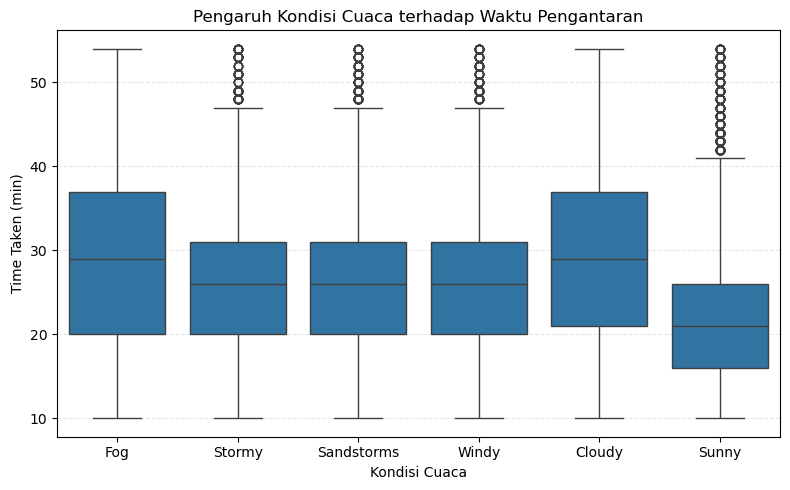

In [ ]:
# Boxplot waktu pengantaran berdasarkan cuaca
plt.figure(figsize=(8,5))
sns.boxplot(x="Weather_conditions", y="Time_taken (min)", data=df)
plt.title("Pengaruh Kondisi Cuaca terhadap Waktu Pengantaran")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Time Taken (min)")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Statistik deskriptif waktu pengantaran berdasarkan kondisi cuaca
weather_stats = df.groupby("Weather_conditions")["Time_taken (min)"].describe()
print(weather_stats)

                     count       mean        std   min   25%   50%   75%   max
Weather_conditions                                                            
Cloudy              6947.0  29.139197  10.030463  10.0  21.0  29.0  37.0  54.0
Fog                 7115.0  29.172593  10.099812  10.0  20.0  29.0  37.0  54.0
Sandstorms          6851.0  26.113414   8.556032  10.0  20.0  26.0  31.0  54.0
Stormy              6995.0  26.108506   8.418584  10.0  20.0  26.0  31.0  54.0
Sunny               6612.0  22.143376   8.325623  10.0  16.0  21.0  26.0  54.0
Windy               6839.0  26.357070   8.527402  10.0  20.0  26.0  31.0  54.0


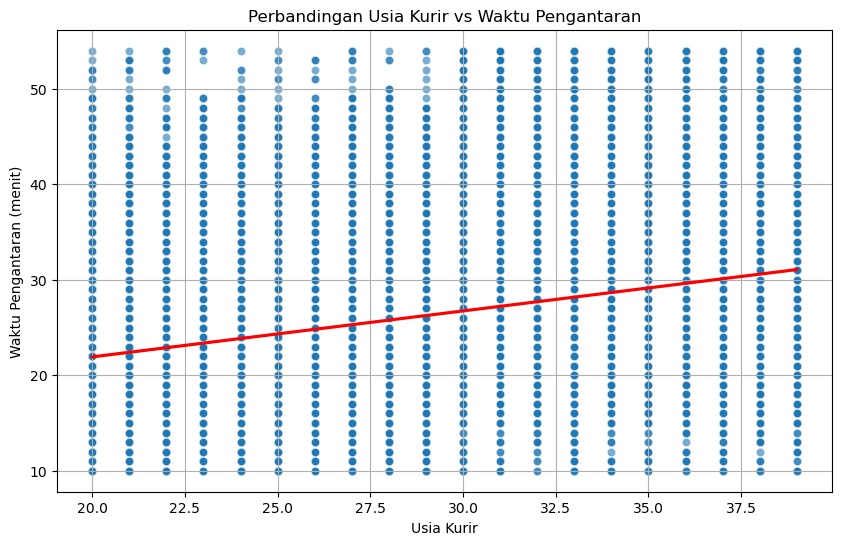

In [ ]:
# Usia kurir vs waktu pengantaran
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Delivery_person_Age', y='Time_taken (min)', alpha=0.6)
sns.regplot(data=df, x='Delivery_person_Age', y='Time_taken (min)', scatter=False, color='red')
plt.title('Perbandingan Usia Kurir vs Waktu Pengantaran')
plt.xlabel('Usia Kurir')
plt.ylabel('Waktu Pengantaran (menit)')
plt.grid(True)
plt.show()

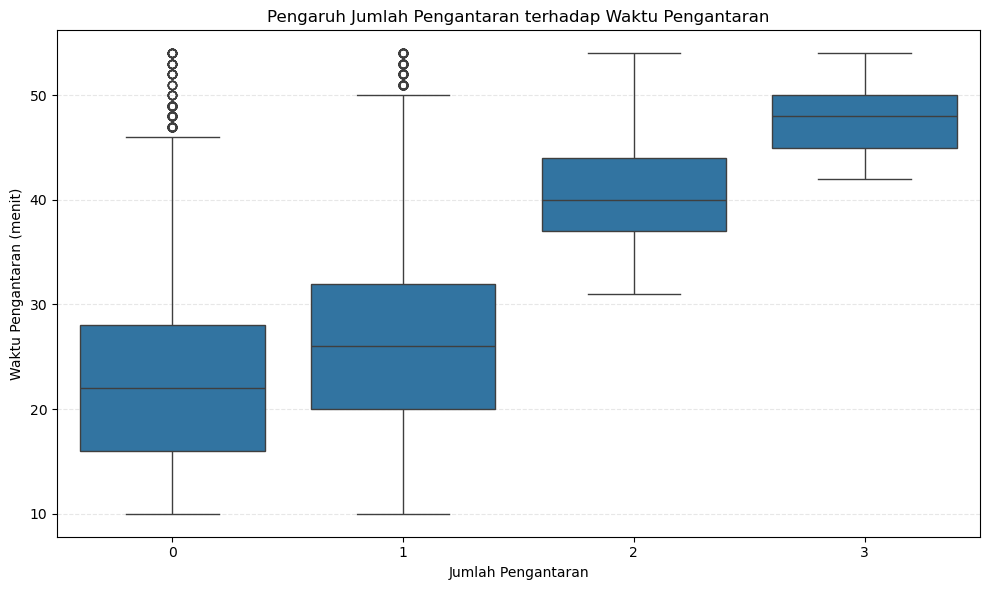

In [ ]:
# pengaruh multiple deliveries
plt.figure(figsize=(10, 6))
sns.boxplot(x='multiple_deliveries', y='Time_taken (min)', data=df)
plt.title('Pengaruh Jumlah Pengantaran terhadap Waktu Pengantaran')
plt.xlabel('Jumlah Pengantaran')
plt.ylabel('Waktu Pengantaran (menit)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Statistik deskriptif pengaruh multiple deliveries
multiple_deliveries_stats = df.groupby("multiple_deliveries")["Time_taken (min)"].describe()
print(multiple_deliveries_stats)

                       count       mean       std   min   25%   50%   75%  \
multiple_deliveries                                                         
0                    12973.0  23.106529  8.729404  10.0  16.0  22.0  28.0   
1                    26168.0  26.986931  8.499743  10.0  20.0  26.0  32.0   
2                     1881.0  40.467836  4.901059  31.0  37.0  40.0  44.0   
3                      337.0  47.827893  3.490641  42.0  45.0  48.0  50.0   

                      max  
multiple_deliveries        
0                    54.0  
1                    54.0  
2                    54.0  
3                    54.0  


* Insightnya :
* Waktu pengantaran meningkat pada kondisi lalu lintas padat
* Titik-titik menunjukkan usia kurir vs lama waktu pengantaran. Pola yang ditemukan adalah kurir lebih muda lebih cepat dalam waktu pengantaran.
* Multiple deliveries cenderung meningkatkan waktu antar.


# Machine Learning

a. Persiapan dataset

In [ ]:
# Pastikan kolom 'Order_Date' dalam format datetime dan konversi menjadi hari sejak tanggal minimum
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Order_Date'] = (df['Order_Date'] - df['Order_Date'].min()).dt.days

In [ ]:
# Mengonversi kolom 'Time_Orderd' dan 'Time_Order_picked' menjadi total menit sejak tengah malam
df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], format='%H:%M:%S', errors='coerce')
df['Time_Orderd'] = df['Time_Orderd'].dt.hour * 60 + df['Time_Orderd'].dt.minute

df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], format='%H:%M:%S', errors='coerce')
df['Time_Order_picked'] = df['Time_Order_picked'].dt.hour * 60 + df['Time_Order_picked'].dt.minute


In [ ]:
# Pastikan tipe data numerik untuk kolom lainnya
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'], errors='coerce')
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce')
df['Restaurant_latitude'] = pd.to_numeric(df['Restaurant_latitude'], errors='coerce')
df['Restaurant_longitude'] = pd.to_numeric(df['Restaurant_longitude'], errors='coerce')
df['Delivery_location_latitude'] = pd.to_numeric(df['Delivery_location_latitude'], errors='coerce')
df['Delivery_location_longitude'] = pd.to_numeric(df['Delivery_location_longitude'], errors='coerce')
df['multiple_deliveries'] = pd.to_numeric(df['multiple_deliveries'], errors='coerce')
df['Festival'] = pd.to_numeric(df['Festival'], errors='coerce')
df['City'] = pd.Categorical(df['City']).codes

In [ ]:
# Target variabel adalah 'Time_taken (min)', dan fitur lainnya adalah semua kolom yang tersisa
X = df_encode.drop(['Time_taken (min)', 'ID', 'Delivery_person_ID'], axis=1)
y = df['Time_taken (min)']

In [ ]:
# Split data : 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Drop datetime columns from the DataFrame
X = X.drop(columns=['Order_Date', 'Time_Orderd', 'Time_Order_picked'], errors='ignore')
X_train = X_train.drop(columns=['Order_Date', 'Time_Orderd', 'Time_Order_picked'], errors='ignore')
X_test = X_test.drop(columns=['Order_Date', 'Time_Orderd', 'Time_Order_picked'], errors='ignore')

b. Pembuatan dan evaluasi model

In [ ]:
# Model Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

In [ ]:
# Model Decision Tree Regressor
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)
y_pred_dt = decision_tree_model.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

In [ ]:
# Model Random Forest Regressor
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

In [ ]:
# Model XGBoost Regressor
xgboost_model = XGBRegressor(random_state=42, verbosity=0)
xgboost_model.fit(X_train, y_train)
y_pred_xgb = xgboost_model.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

In [ ]:
# Menampilkan hasil evaluasi
print(f"Linear Regression: MAE: {mae_linear:.2f} | RMSE: {rmse_linear:.2f} | R²: {r2_linear:.3f}")
print(f"Decision Tree Regressor: MAE: {mae_dt:.2f} | RMSE: {rmse_dt:.2f} | R²: {r2_dt:.3f}")
print(f"Random Forest Regressor: MAE: {mae_rf:.2f} | RMSE: {rmse_rf:.2f} | R²: {r2_rf:.3f}")
print(f"XGBoost Regressor: MAE: {mae_xgb:.2f} | RMSE: {rmse_xgb:.2f} | R²: {r2_xgb:.3f}")


Linear Regression: MAE: 4.72 | RMSE: 5.92 | R²: 0.601
Decision Tree Regressor: MAE: 4.88 | RMSE: 6.52 | R²: 0.515
Random Forest Regressor: MAE: 3.70 | RMSE: 4.76 | R²: 0.742
XGBoost Regressor: MAE: 3.50 | RMSE: 4.42 | R²: 0.777


" Insight :"
1. XGBoost Regressor menunjukkan performansi terbaik di semua metrik:
* MAE dan RMSE paling rendah → model ini membuat prediksi paling dekat dengan nilai aktual.
* R² = 0.777 menunjukkan bahwa hampir 78% variabilitas waktu pengiriman bisa dijelaskan oleh model ini.
2. Linear Regression cukup baik, tapi terlalu sederhana untuk menangkap kompleksitas fitur.
3. Decision Tree terlalu mudah overfitting atau underfitting (tergantung pada setting).
4. Random Forest menunjukkan performa solid, namun sedikit di bawah XGBoost.

c. Visualisasi Actual vs Predicted (XGBoost)

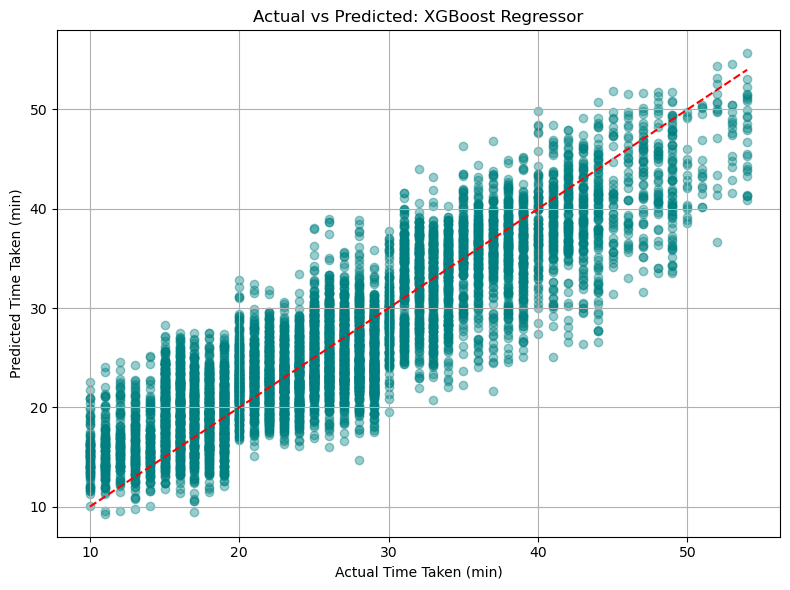

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Time Taken (min)')
plt.ylabel('Predicted Time Taken (min)')
plt.title('Actual vs Predicted: XGBoost Regressor')
plt.grid(True)
plt.tight_layout()
plt.show()

 Interpretasi: Titik-titik yang berada dekat garis merah putus-putus menunjukkan prediksi yang akurat. Semakin tersebar, semakin besar kesalahan.

d. Hyperparameter Tuning & Cross-Validation (XGBoost)

In [ ]:
#1. Grid Search with Cross-Validation
# Parameter grid untuk tuning
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

In [ ]:
# Inisialisasi model dasar
xgb_model = XGBRegressor(random_state=42)

In [ ]:
# GridSearch dengan 5-fold CV
grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           scoring='neg_root_mean_squared_error',
                           cv=5,
                           verbose=1,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 150],
                         'subsample': [0.8, 1.0]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [ ]:
# Model terbaik dari hasil tuning
best_xgb = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 150, 'subsample': 1.0}


In [ ]:
# Prediksi dan evaluasi model terbaik
y_pred_best = best_xgb.predict(X_test)
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print(f"Best XGBoost: MAE = {mae_best:.2f} | RMSE = {rmse_best:.2f} | R² = {r2_best:.3f}")


Best XGBoost: MAE = 3.47 | RMSE = 4.38 | R² = 0.781


# Kesimpulan
* ✅ XGBoost Regressor adalah model terbaik berdasarkan MAE, RMSE, dan R².
* 📈 Visualisasi Actual vs Predicted menunjukkan bahwa model sudah cukup akurat.
* 🔧 Tuning hyperparameter menggunakan GridSearchCV meningkatkan akurasi prediksi.
* 📊 Cross-validation memberikan evaluasi performa yang lebih generalisable.